In [ ]:
#Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
#Function for performance metrics
def print_metrics(y_test, y_pred, model_name):
  print(f"\n{model_name} Performance Metrics :")
  print(f"\Accuracy : {accuracy_score(y_test, y_pred)*100:.4f}%")
  print(f"\Precision : {precision_score(y_test, y_pred, average='weighted')*100:.4f}%")
  print(f"\Recall : {recall_score(y_test, y_pred, average='weighted')*100:.4f}%")
  print(f"\F1-Score : {f1_score(y_test, y_pred, average='weighted')*100:.4f}%")

  #Print confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  print(f"Confusion Metrix : ")
  sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', linewidths=3, xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(f'{model_name} Confusion Matrix')
  plt.show()

In [ ]:
#Load the dataset
file_path  = '/content/Network_anomaly_data.csv'
data = pd.read_csv(file_path)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   protocoltype            125973 non-null  object 
 2   service                 125973 non-null  object 
 3   flag                    125973 non-null  object 
 4   srcbytes                125973 non-null  int64  
 5   dstbytes                125973 non-null  int64  
 6   land                    125973 non-null  int64  
 7   wrongfragment           125973 non-null  int64  
 8   urgent                  125973 non-null  int64  
 9   hot                     125973 non-null  int64  
 10  numfailedlogins         125973 non-null  int64  
 11  loggedin                125973 non-null  int64  
 12  numcompromised          125973 non-null  int64  
 13  rootshell               125973 non-null  int64  
 14  suattempted         

In [ ]:
data.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
data.describe()

,duration,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag,attack_encoded
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060,10.625483
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503,2.636084
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,9.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,11.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000,11.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,22.000000


In [ ]:
data.isnull().sum()

,0
duration,0
protocoltype,0
service,0
flag,0
srcbytes,0
dstbytes,0
land,0
wrongfragment,0
urgent,0
hot,0


In [ ]:
data.shape

(125973, 44)

In [ ]:
data.dtypes.value_counts()

,count
int64,24
float64,15
object,4


In [ ]:
#Encode the target variable('attack')
label_encoder = LabelEncoder()
data['attack_encoded'] = label_encoder.fit_transform(data['attack'])

In [ ]:
#Find the categorical columns
categorical_columns = ['protocoltype', 'service', 'flag']

#One-hot encoding for categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

In [ ]:
#Seperate features and target variables
X = data_encoded.drop(columns=['attack', 'attack_encoded', 'lastflag'])
y = data_encoded['attack_encoded']

In [ ]:
#Mapping for attack_encoded values and attack labels
attack_mapping = {i:label for i, label in enumerate(label_encoder.classes_)}
print("Mapping for attack_encoded to attack labels:")
for encoded_value, label in attack_mapping.items():
    print(f"{encoded_value}: {label}")


Mapping for attack_encoded to attack labels:
0: back
1: buffer_overflow
2: ftp_write
3: guess_passwd
4: imap
5: ipsweep
6: land
7: loadmodule
8: multihop
9: neptune
10: nmap
11: normal
12: perl
13: phf
14: pod
15: portsweep
16: rootkit
17: satan
18: smurf
19: spy
20: teardrop
21: warezclient
22: warezmaster


In [ ]:
#Normalize Features
scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

In [ ]:
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
#Multi Layer Perceptron model
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(X_train.shape[1],)

119


In [ ]:
#Compile Model
mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#Fit model
history = mlp_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8542 - loss: 0.6044 - val_accuracy: 0.9731 - val_loss: 0.0927
Epoch 2/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9672 - loss: 0.1095 - val_accuracy: 0.9860 - val_loss: 0.0579
Epoch 3/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9799 - loss: 0.0696 - val_accuracy: 0.9872 - val_loss: 0.0521
Epoch 4/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9833 - loss: 0.0586 - val_accuracy: 0.9885 - val_loss: 0.0482
Epoch 5/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0509 - val_accuracy: 0.9904 - val_loss: 0.0436
Epoch 6/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9873 - loss: 0.0434 - val_accuracy: 0.9903 - val_loss: 0.0434
Epoch 7/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9875 - loss: 0.0421 - val_accuracy: 0.9907 - val_loss: 0.0431
Epoch 8/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9892 - loss: 0.0387 - 

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
#Evaluate Model
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"MLP Test Accuracy: {mlp_test_accuracy*100:.5f}%")

MLP Test Accuracy: 99.16384%


In [ ]:
# Predicting class probabilities
y_pred_mlp_prob = mlp_model.predict(X_test)  # Get class probabilities, not class labels

1181/1181 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
# If y_pred_mlp_prob is probabilities
y_pred_mlp = y_pred_mlp_prob.argmax(axis=1)  # Get class labels from probabilities

In [ ]:
# Print the shapes of y_test and y_pred_mlp
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_pred_mlp: {y_pred_mlp.shape}")
print(f"Shape of y_pred_mlp_prob: {y_pred_mlp_prob.shape}")

Shape of y_test: (37792,)
Shape of y_pred_mlp: (37792,)
Shape of y_pred_mlp_prob: (37792, 23)



MLP Performance Metrics :
\Accuracy : 99.1638%
\Precision : 99.1212%
\Recall : 99.1638%
\F1-Score : 99.0987%
Confusion Metrix : 


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


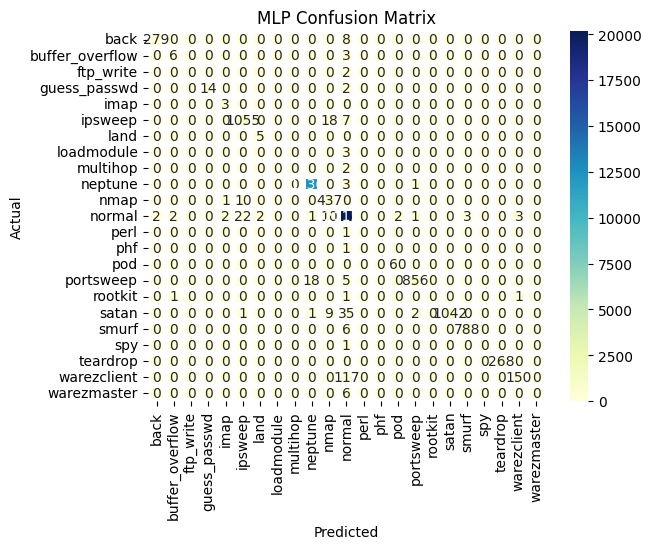

In [ ]:
# Print performance metrics
print_metrics(y_test, y_pred_mlp, 'MLP')

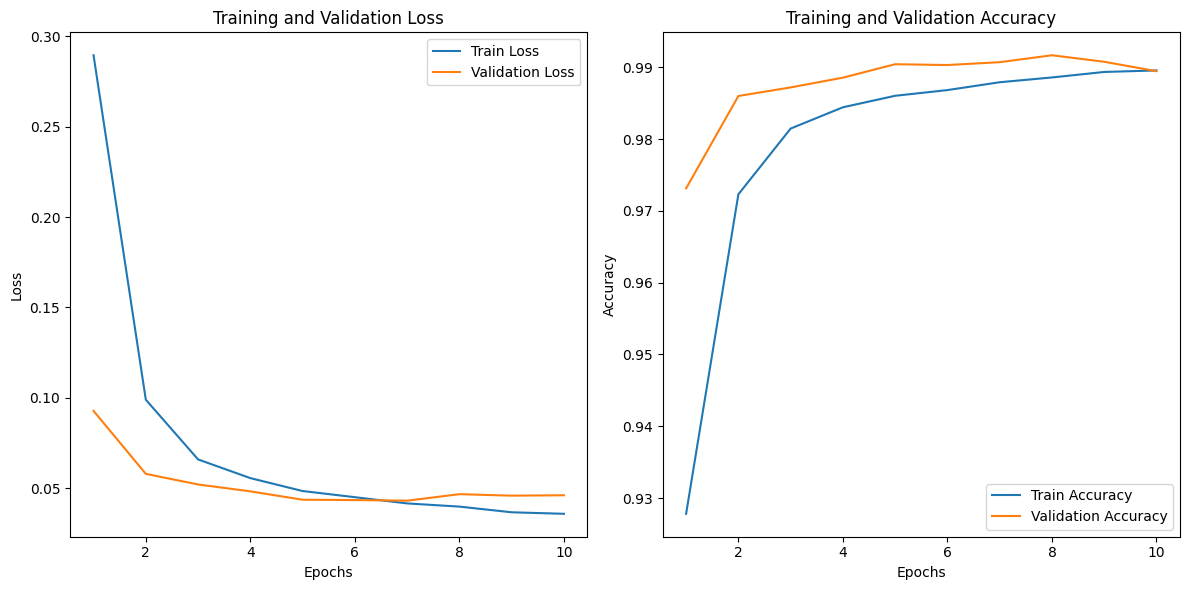

In [ ]:
# Get the training and validation loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


# Plot the loss curves (Training vs Validation)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot the accuracy curves (Training vs Validation)
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label='Train Accuracy')
plt.plot(range(1, len(val_accuracy) + 1), val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
